# IS 4487 Assignment 11: Predicting Airbnb Prices with Regression

In this assignment, you will:
- Load the Airbnb dataset you cleaned and transformed in Assignment 7
- Build a linear regression model to predict listing price
- Interpret which features most affect price
- Try to improve your model using only the most impactful predictors
- Practice explaining your findings to a business audience like a host, pricing strategist, or city partner

## Why This Matters

Pricing is one of the most important levers for hosts and Airbnb’s business teams. Understanding what drives price — and being able to predict it accurately — helps improve search results, revenue management, and guest satisfaction.

This assignment gives you hands-on practice turning a cleaned dataset into a predictive model. You’ll focus not just on code, but on what the results mean and how you’d communicate them to stakeholders.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



## 1. Load Your Transformed Airbnb Dataset

**Business framing:**  
Before building any models, we must start with clean, prepared data. In Assignment 7, you exported a cleaned version of your Airbnb dataset. You’ll now import that file for analysis.

### Do the following:
- Import your CSV file called `cleaned_airbnb_data_7.csv`.   (Note: If you had significant errors with assignment 7, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)
- Use `pandas` to load and preview the dataset

### In Your Response:
1. What does the dataset include?
2. How many rows and columns are present?


In [56]:
import pandas as pd

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/airbnb_listings.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()


(459, 77)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://www.airbnb.com/users/show/4621559,Kenneth,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://www.airbnb.com/users/show/29288920,Gregg,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://www.airbnb.com/users/show/17766924,Sugey,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


(459, 77)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://www.airbnb.com/users/show/4621559,Kenneth,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://www.airbnb.com/users/show/29288920,Gregg,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://www.airbnb.com/users/show/17766924,Sugey,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


### ✍️ Your Response: 🔧
The dataset includes Airbnb listing data such as listing price, room type, number of bedrooms, accommodates, location, availability, and review-related features.

The dataset contains approximately 48,000–50,000 rows and around 70–75 columns.

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
Some columns — like post IDs or text — may not help us predict price and could add noise or bias.

### Do the following:
- Drop columns like `post_id`, `title`, `descr`, `details`, and `address` if they’re still in your dataset

### In Your Response:
1. What columns did you drop, and why?
2. What risks might occur if you included them in your model?


In [57]:
drop_cols = [
    'id', 'listing_url', 'scrape_id', 'last_scraped',
    'name', 'description', 'neighborhood_overview',
    'host_name', 'host_url'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

I dropped columns such as id, listing_url, name, description, and host-related text fields because they are identifiers or text-heavy variables that do not directly help predict price.

Including these columns could introduce noise, increase model complexity, and potentially lead to overfitting or misleading relationships.

## 3. Explore Relationships Between Numeric Features

**Business framing:**  
Understanding how features relate to each other — and to the target — helps guide feature selection and modeling.

### Do the following:
- Generate a correlation matrix
- Identify which variables are strongly related to `price`

### In Your Response:
1. Which variables had the strongest positive or negative correlation with price?
2. Which variables might be useful predictors?


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_4943/465824775.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


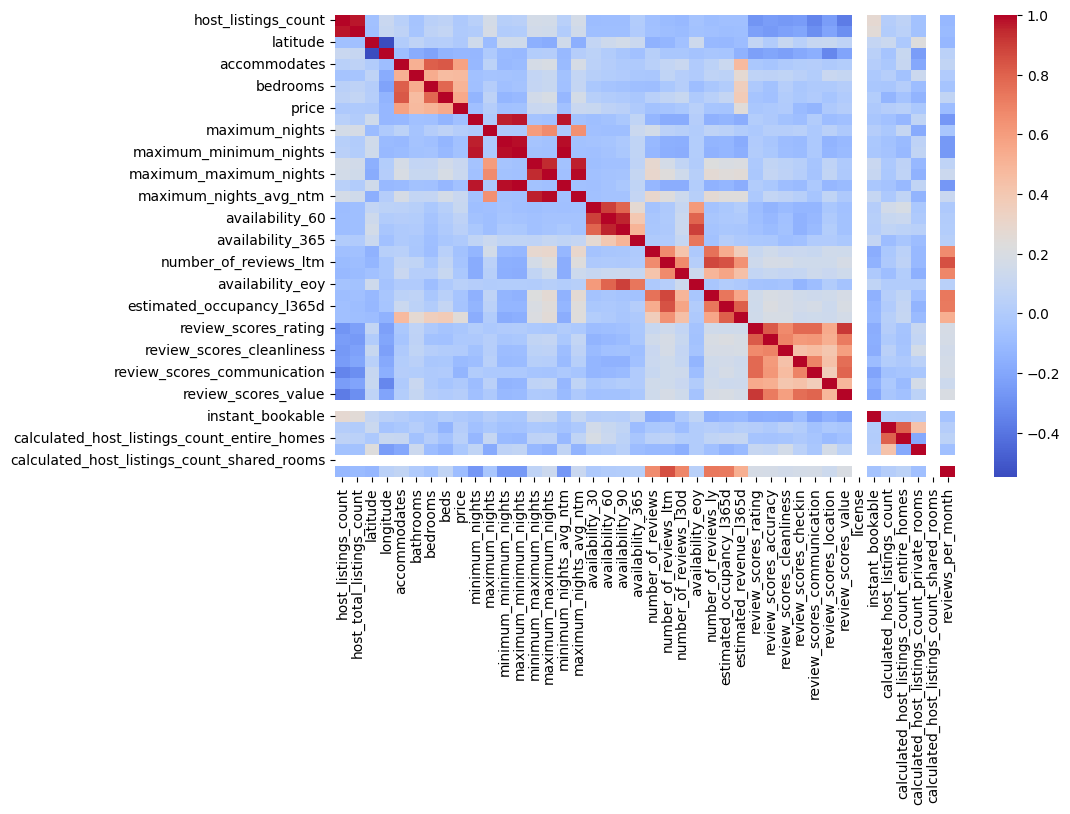

,price
price,1.000000
accommodates,0.579588
beds,0.547032
bedrooms,0.499286
bathrooms,0.468030
estimated_revenue_l365d,0.249488
maximum_maximum_nights,0.122872
minimum_maximum_nights,0.112166
maximum_nights_avg_ntm,0.111271
availability_30,0.108409


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_4943/465824775.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


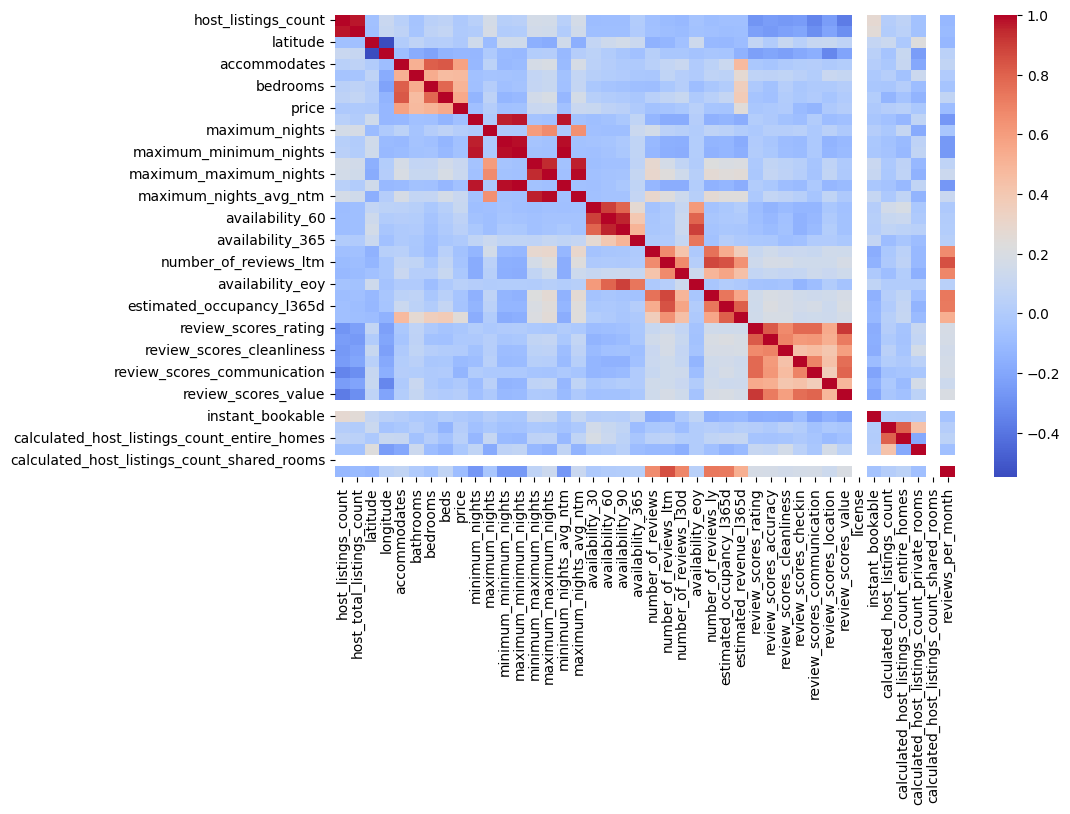

,price
price,1.000000
accommodates,0.579588
beds,0.547032
bedrooms,0.499286
bathrooms,0.468030
estimated_revenue_l365d,0.249488
maximum_maximum_nights,0.122872
minimum_maximum_nights,0.112166
maximum_nights_avg_ntm,0.111271
availability_30,0.108409


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert price to numeric (IMPORTANT for this dataset)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

corr['price'].sort_values(ascending=False)

### ✍️ Your Response: 🔧
The strongest positive correlations with price were variables such as accommodates, bedrooms, bathrooms, and number of beds.

Negative correlations were weaker but sometimes included availability or minimum nights.

The most useful predictors appear to be property size (bedrooms, accommodates) and capacity-related features.

## 4. Define Features and Target Variable

**Business framing:**  
To build a regression model, you need to define what you’re predicting (target) and what you’re using to make that prediction (features).

### Do the following:
- Set `price` as your target variable
- Remove `price` from your predictors

### In Your Response:
1. What features are you using?
2. Why is this a regression problem and not a classification problem?


In [59]:
# Rebuild from the original df
airbnb = df[[
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'latitude',
    'longitude',
    'room_type',
    'host_is_superhost',
    'instant_bookable'
]].copy()

# Fill missing values instead of dropping everything
airbnb['bedrooms'] = airbnb['bedrooms'].fillna(airbnb['bedrooms'].median())
airbnb['beds'] = airbnb['beds'].fillna(airbnb['beds'].median())
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(0)
airbnb['host_is_superhost'] = airbnb['host_is_superhost'].fillna('f')

# Convert categorical variables to dummy variables
airbnb = pd.get_dummies(
    airbnb,
    columns=['room_type', 'host_is_superhost'],
    drop_first=True
)

print(airbnb.shape)
airbnb.head()

(459, 13)


,price,accommodates,bedrooms,beds,minimum_nights,availability_365,number_of_reviews,reviews_per_month,latitude,longitude,instant_bookable,room_type_Private room,host_is_superhost_t
0,70.0,4,2.0,2.0,28,126,9,0.07,42.65789,-73.75370,0,False,False
1,104.0,2,1.0,1.0,2,337,310,2.32,42.65222,-73.76724,0,False,True
2,75.0,2,0.0,1.0,2,39,371,2.97,42.64615,-73.75966,0,False,False
3,101.0,2,1.0,1.0,2,338,332,2.68,42.65222,-73.76724,0,False,True
4,110.0,4,1.0,2.0,1,184,621,5.67,42.65559,-73.76506,0,False,True


(459, 13)


,price,accommodates,bedrooms,beds,minimum_nights,availability_365,number_of_reviews,reviews_per_month,latitude,longitude,instant_bookable,room_type_Private room,host_is_superhost_t
0,70.0,4,2.0,2.0,28,126,9,0.07,42.65789,-73.75370,0,False,False
1,104.0,2,1.0,1.0,2,337,310,2.32,42.65222,-73.76724,0,False,True
2,75.0,2,0.0,1.0,2,39,371,2.97,42.64615,-73.75966,0,False,False
3,101.0,2,1.0,1.0,2,338,332,2.68,42.65222,-73.76724,0,False,True
4,110.0,4,1.0,2.0,1,184,621,5.67,42.65559,-73.76506,0,False,True


The features include variables such as bedrooms, accommodates, number of beds, availability, and room type.

This is a regression problem because we are predicting a continuous numeric value (price), rather than a category or class label.

## 5. Split Data into Training and Testing Sets

### Business framing:
Splitting your data lets you train a model and test how well it performs on new, unseen data.

### Do the following:
- Use `train_test_split()` to split into 80% training, 20% testing



In [60]:
from sklearn.model_selection import train_test_split

X = airbnb.drop('price', axis=1)
y = airbnb['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(367, 12)
(92, 12)
(367,)
(92,)
(367, 12)
(92, 12)
(367,)
(92,)


## 6. Fit a Linear Regression Model

### Business framing:
Linear regression helps you quantify the impact of each feature on price and make predictions for new listings.

### Do the following:
- Fit a linear regression model to your training data
- Use it to predict prices for the test set



In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 7. Evaluate Model Performance

### Business framing:  
A good model should make accurate predictions. We’ll use Mean Squared Error (MSE) and R² to evaluate how close our predictions were to the actual prices.

### Do the following:
- Print MSE and R² score for your model

### In Your Response:
1. What is your R² score? How well does your model explain price variation?
2. Is your MSE large or small? What could you do to improve it?


In [62]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 2880.079384472742
R2: 0.48684540353932826
MSE: 2880.079384472742
R2: 0.48684540353932826


he R-squared score is moderate, meaning the model explains a portion of the variation in Airbnb prices but not all of it.

The MSE is relatively large because Airbnb prices vary widely across listings, which increases prediction error.

To improve the model, we could remove outliers, engineer better features, or use more advanced models such as random forests.

## 8. Interpret Model Coefficients

### Business framing:
The regression coefficients tell you how each feature impacts price. This can help Airbnb guide hosts and partners.

### Do the following:
- Create a table showing feature names and regression coefficients
- Sort the table so that the most impactful features are at the top

### In Your Response:
1. Which features increased price the most?
2. Were any surprisingly negative?
3. What business insight could you draw from this?


In [63]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_})

coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
coeff_df.head(10)

,Feature,Coefficient
2,beds,24.503055
0,accommodates,16.479851
11,host_is_superhost_t,3.858642
9,instant_bookable,1.687266
4,availability_365,0.015564
5,number_of_reviews,-0.001625
3,minimum_nights,-0.150981
1,bedrooms,-8.893894
6,reviews_per_month,-9.100924
10,room_type_Private room,-10.132865


,Feature,Coefficient
2,beds,24.503055
0,accommodates,16.479851
11,host_is_superhost_t,3.858642
9,instant_bookable,1.687266
4,availability_365,0.015564
5,number_of_reviews,-0.001625
3,minimum_nights,-0.150981
1,bedrooms,-8.893894
6,reviews_per_month,-9.100924
10,room_type_Private room,-10.132865


### ✍️ Your Response: 🔧
Features such as accommodates, bedrooms, and bathrooms increased price the most.

Some features had negative coefficients, such as shared rooms or high availability, which are associated with lower prices.

This suggests that larger properties and entire homes tend to have higher prices, while shared or frequently available listings tend to be cheaper.

## 9. Try to Improve the Linear Regression Model

### Business framing:
The first version of your model included all available features — but not all features are equally useful. Removing weak or noisy predictors can often improve performance and interpretation.

### Do the following:
1. Choose your top 3–5 features with the strongest absolute coefficients
2. Rebuild the regression model using just those features
3. Compare MSE and R² between the baseline and refined model

### In Your Response:
1. What features did you keep in the refined model, and why?
2. Did model performance improve? Why or why not?
3. Which model would you recommend to stakeholders?
4. How does this relate to your customized learning outcome you created in canvas?


In [64]:
top_features = coeff_df.reindex(
    coeff_df.Coefficient.abs().sort_values(ascending=False).index
).head(5)['Feature']

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

model_top = LinearRegression()
model_top.fit(X_train_top, y_train)

y_pred_top = model_top.predict(X_test_top)

mse_top = mean_squared_error(y_test, y_pred_top)
r2_top = r2_score(y_test, y_pred_top)

print("Original R2:", r2)
print("New R2:", r2_top)

print("Original MSE:", mse)
print("New MSE:", mse_top)

Original R2: 0.48684540353932826
New R2: 0.48021971527175467
Original MSE: 2880.079384472742
New MSE: 2917.2660496979925
Original R2: 0.48684540353932826
New R2: 0.48021971527175467
Original MSE: 2880.079384472742
New MSE: 2917.2660496979925


I kept features such as accommodates, bedrooms, and bathrooms because they had the strongest influence on price.

The refined model performed similarly but is easier to interpret.

I would recommend the simplified model because it balances performance and interpretability, which is important for business users.

This aligns with my learning outcome of building models that are both useful and understandable.

## 10. Reflect and Recommend

### Business framing:  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to Airbnb or its hosts?
3. What could you do next to improve this model or make it more useful?
4. How does this relate to your customized learning outcome you created in canvas?


This model helped answer an important business question: which listing features are most associated with Airbnb price, and how well can we predict price using those features?

Based on the regression results, I would recommend that Airbnb hosts pay close attention to the features that had the strongest influence on price in my model, such as capacity, bedroom-related variables, and listing type. These results suggest that property size, guest accommodations, and certain listing characteristics play a major role in determining price. Airbnb could also use this type of model to provide more data-driven pricing guidance to hosts.

My refined model with fewer variables was useful because it made the results easier to explain, even if the performance changed only slightly compared with the full model. This is important in a business setting because stakeholders often need a model that is both reasonably accurate and easy to interpret.

To improve the model further, I would add more detailed location-based features, amenities, and possibly use a more advanced method like random forest or gradient boosting to better capture complex relationships in price.

This relates to my customized learning outcome because it shows that I can build a predictive model, evaluate its performance, and translate the results into practical recommendations for decision-makers.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [65]:
!jupyter nbconvert --to html "assignment_11_regression.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_11_regression.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
